# Algortimos supervisados o semi supervisados

In [7]:
#Cargar datos
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier, LinearSVC, LogisticRegression, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, count

# 1. Iniciamos Spark
spark = SparkSession.builder.appName("Semana12_Supervisados_Computadores").getOrCreate()

# 2. Leemos los datos etiquetados (los que guardamos del clustering)
ruta_datos = "/home/jovyan/work/semanas/Semana10/modelos/notebooks_etiquetados"

try:
    df_clusters = spark.read.parquet(ruta_datos)
    print(f"Datos cargados desde {ruta_datos}")
except:
    # Si no existe, usar df_clusters de memoria
    if 'df_clusters' in dir():
        df_clusters = df_clusters
        print("Usando df_clusters desde memoria")
    elif 'df_clusters_corregido' in dir():
        df_clusters = df_clusters_corregido
        print("Usando df_clusters_corregido desde memoria")
    else:
        print("No se encontraron datos. Ejecuta primero el clustering.")

# 4. Mostramos la tabla para comprobar
print(f"Datos cargados: {df_clusters.count()} registros")
df_clusters.printSchema()
df_clusters.show(5, truncate=False)

Datos cargados desde /home/jovyan/work/semanas/Semana10/modelos/notebooks_etiquetados
Datos cargados: 2075 registros
root
 |-- precio_entero: double (nullable = true)
 |-- ram_gb: double (nullable = true)
 |-- almacenamiento_gb: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- pcaFeatures: vector (nullable = true)
 |-- prediction: integer (nullable = true)

+-------------+------+-----------------+-----------------------+---------------------------------------------------------------+-------------------------------------------+----------+
|precio_entero|ram_gb|almacenamiento_gb|features               |scaledFeatures                                                 |pcaFeatures                                |prediction|
+-------------+------+-----------------+-----------------------+---------------------------------------------------------------+-------------------------------------------+----------+
|888362.0     |16.0  

## Árbol de decisión

In [8]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
# Configurar el modelo supervisado
df_supervisado = df_clusters.withColumnRenamed("prediction", "label")

train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)
print(f"Datos de entrenamiento: {train_data.count()}")
print(f"Datos de prueba: {test_data.count()}")

Datos de entrenamiento: 1503
Datos de prueba: 572


In [11]:
# Configurar el modelo supervisado
# Usamos 'scaledFeatures' como entrada (featuresCol) y 'label' como el grupo a predecir
dt = DecisionTreeClassifier(featuresCol="scaledFeatures", labelCol="label", maxDepth=5, seed=42)

# Entrenar el modelo con los datos de entrenamiento
dt_model = dt.fit(train_data)

# Hacer predicciones sobre los datos de prueba
predictions_supervisadas = dt_model.transform(test_data)

# Mostrar las primeras predicciones junto a la etiqueta real del K-Means
predictions_supervisadas.select("label", "prediction", "precio_entero", "ram_gb", "almacenamiento_gb").show(15, truncate=False)

+-----+----------+-------------+------+-----------------+
|label|prediction|precio_entero|ram_gb|almacenamiento_gb|
+-----+----------+-------------+------+-----------------+
|3    |3.0       |170879.0     |8.0   |128.0            |
|3    |3.0       |179910.0     |4.0   |120.0            |
|3    |3.0       |179910.0     |4.0   |127.0            |
|3    |3.0       |179910.0     |8.0   |121.0            |
|3    |3.0       |179991.0     |4.0   |120.0            |
|3    |3.0       |181990.0     |4.0   |4.0              |
|3    |3.0       |188443.0     |4.0   |4.0              |
|3    |3.0       |189990.0     |8.0   |256.0            |
|3    |3.0       |199057.0     |4.0   |64.0             |
|0    |0.0       |199990.0     |4.0   |500.0            |
|3    |3.0       |200000.0     |8.0   |128.0            |
|3    |3.0       |229990.0     |4.0   |128.0            |
|0    |0.0       |229990.0     |4.0   |500.0            |
|3    |3.0       |232990.0     |32.0  |32.0             |
|3    |3.0    

In [12]:
# Evaluar la precisión
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions_supervisadas)

print(f"Precisión del Árbol de Decisión (Accuracy): {accuracy * 100:.2f}%")

Precisión del Árbol de Decisión (Accuracy): 98.25%


In [13]:
print("=== ESTRUCTURA LÓGICA DEL ÁRBOL ===")
print(dt_model.toDebugString)

=== ESTRUCTURA LÓGICA DEL ÁRBOL ===
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_2189818cdf9e, depth=5, numNodes=25, numClasses=5, numFeatures=3
  If (feature 0 <= 0.18878013709794525)
   If (feature 2 <= -0.6251829599370511)
    If (feature 1 <= 0.2876754565289019)
     If (feature 0 <= 0.058257007433309124)
      Predict: 3.0
     Else (feature 0 > 0.058257007433309124)
      If (feature 2 <= -1.5077516640637176)
       Predict: 3.0
      Else (feature 2 > -1.5077516640637176)
       Predict: 1.0
    Else (feature 1 > 0.2876754565289019)
     Predict: 1.0
   Else (feature 2 > -0.6251829599370511)
    If (feature 1 <= 1.688752400781916)
     If (feature 0 <= -0.011431617612877552)
      Predict: 0.0
     Else (feature 0 > -0.011431617612877552)
      If (feature 2 <= 0.47802792022128227)
       Predict: 0.0
      Else (feature 2 > 0.47802792022128227)
       Predict: 2.0
    Else (feature 1 > 1.688752400781916)
     Predict: 4.0
  Else (feature 0 > 0.18878013709794525)


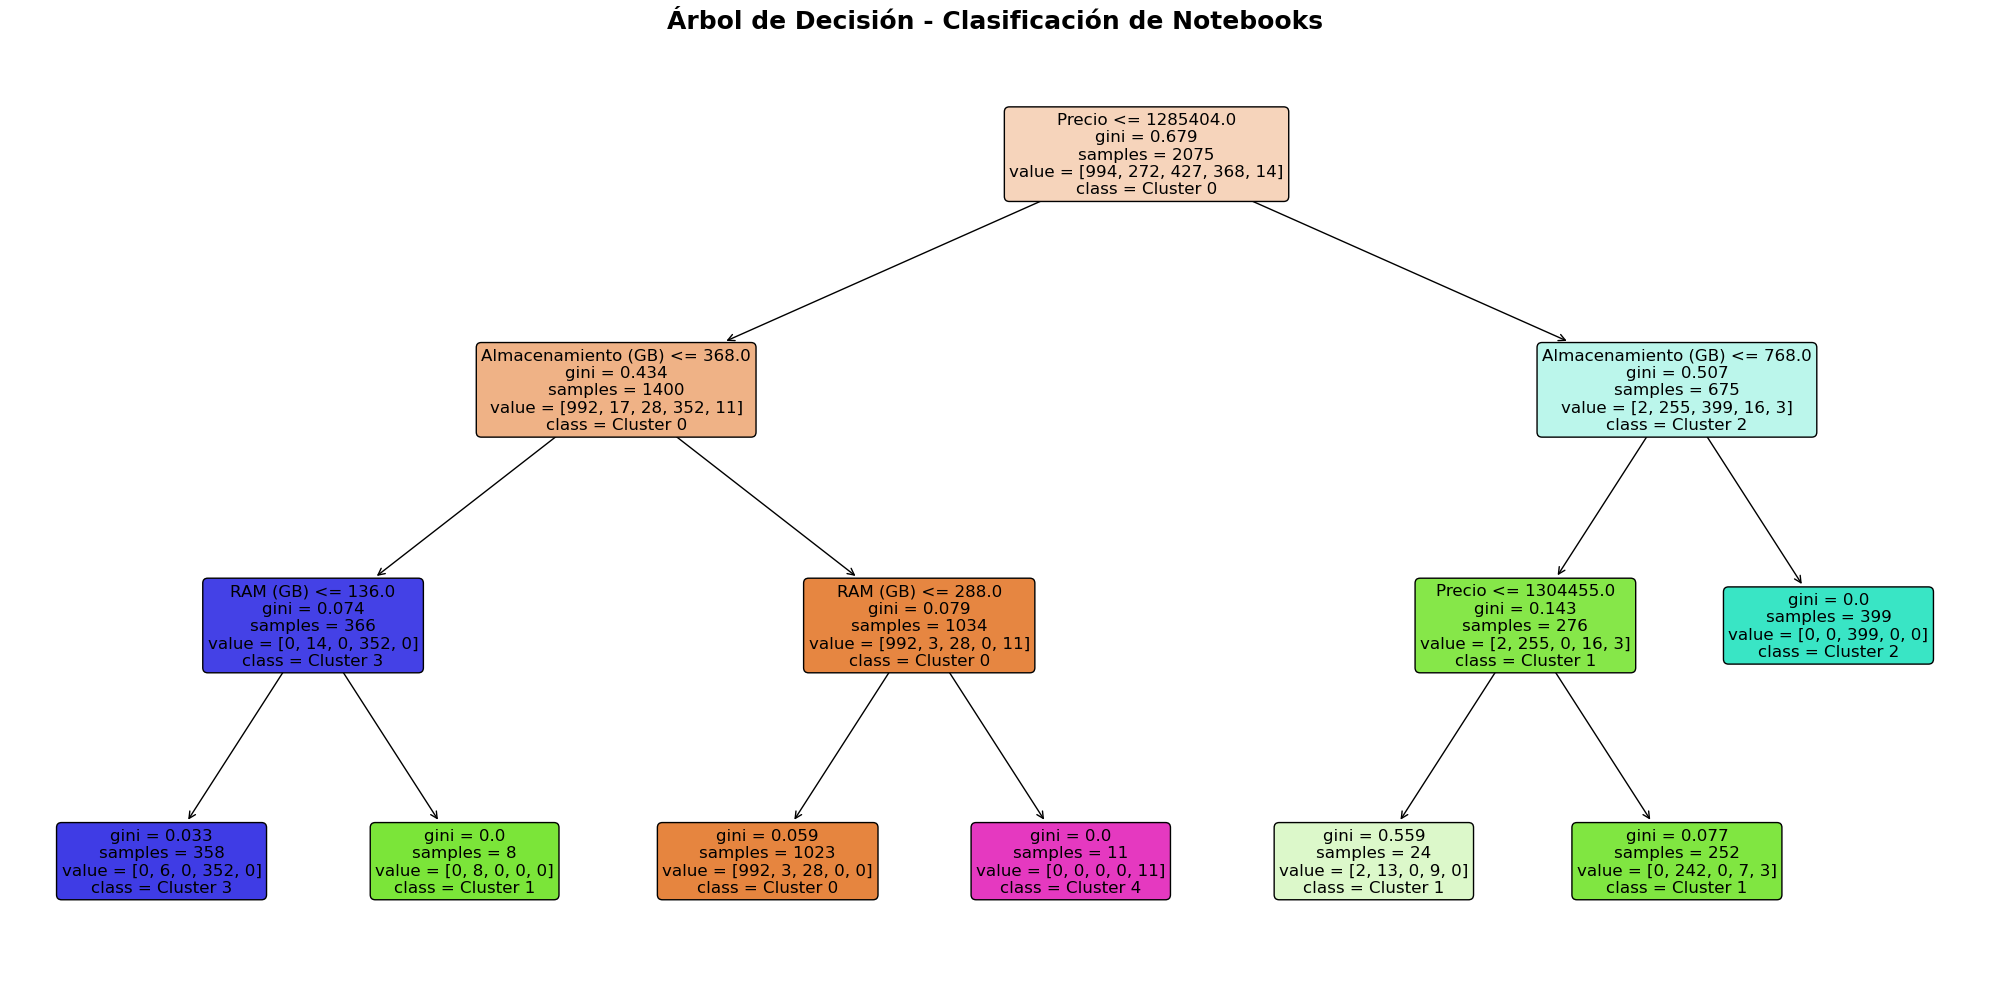

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier

# 1. Convertimos una muestra de nuestro DataFrame de Spark a Pandas para Scikit-Learn
# Usamos las columnas numéricas que tienes disponibles: precio_entero, ram_gb, almacenamiento_gb
df_pandas = df_supervisado.select("precio_entero", "ram_gb", "almacenamiento_gb", "label").toPandas()

# 2. Separamos las características (X) y la etiqueta (y)
X_muestra = df_pandas[["precio_entero", "ram_gb", "almacenamiento_gb"]]
y_muestra = df_pandas["label"]

# 3. Entrenamos el modelo de Scikit-Learn
sk_dt = SklearnClassifier(max_depth=3, random_state=42)  # Limitamos la profundidad a 3 para que no sea gigante
sk_dt.fit(X_muestra, y_muestra)

# 4. Configuramos las etiquetas para el gráfico
nombres_features = ["Precio", "RAM (GB)", "Almacenamiento (GB)"]
# Convertimos los números de cluster a texto para que sea más didáctico
nombres_clases = [f"Cluster {int(c)}" for c in sorted(y_muestra.unique())]

# 5. Dibujamos el árbol de forma visual
plt.figure(figsize=(20, 10), dpi=100)
plot_tree(sk_dt, 
          feature_names=nombres_features, 
          class_names=nombres_clases, 
          filled=True,      # Le pone colores según la clase mayoritaria
          rounded=True,     # Bordes redondeados para estética
          fontsize=12)      # Tamaño de letra legible

plt.title("Árbol de Decisión - Clasificación de Notebooks", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## Random Forest

In [17]:
# 1. Renombramos 'prediction' (del K-Means) a 'label'
if 'df_supervisado' in dir():
    df_supervisado = df_supervisado.withColumnRenamed("prediction", "label")
elif 'df_clusters' in dir():
    df_supervisado = df_clusters.withColumnRenamed("prediction", "label")
else:
    print("No hay DataFrame disponible. Asegúrate de haber ejecutado el clustering primero.")
    df_supervisado = df_clusters

# 2. Dividimos en 70% entrenamiento y 30% prueba

train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

print(f"Registros de Entrenamiento: {train_data.count()}")
print(f"Registros de Prueba: {test_data.count()}")

Registros de Entrenamiento: 1503
Registros de Prueba: 572


In [18]:
from pyspark.ml.classification import RandomForestClassifier, LinearSVC, LogisticRegression, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Creamos el evaluador común para medir el Accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# ==========================================
# MODELO 1: Random Forest (Bosque Aleatorio)
# ==========================================
# Usamos 'scaledFeatures' como entrada
rf = RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label", numTrees=20, seed=42)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)
accuracy_rf = evaluator.evaluate(rf_predictions)

# ==========================================
# MODELO 2: SVM (Máquina de Vectores de Soporte)
# ==========================================
# En PySpark, LinearSVC solo soporta clasificación binaria (0 o 1). 
# Como nuestro K-Means generó varios clusters, usamos 'OneVsRest' 
# para permitir que el SVM clasifique múltiples clases.
svm_binario = LinearSVC(featuresCol="scaledFeatures", labelCol="label", maxIter=10)
ovr_svm = OneVsRest(classifier=svm_binario, labelCol="label", featuresCol="scaledFeatures")
svm_model = ovr_svm.fit(train_data)
svm_predictions = svm_model.transform(test_data)
accuracy_svm = evaluator.evaluate(svm_predictions)

# ==========================================
# MODELO 3: Regresión Logística Multinomial
# ==========================================
# Ideal para problemas multiclase y calcula probabilidades por cada cluster.
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label", maxIter=10, family="multinomial")
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)
accuracy_lr = evaluator.evaluate(lr_predictions)

In [19]:
print("==================================================")
print("  RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12)  ")
print("==================================================")
print(f"1. Random Forest Accuracy:      {accuracy_rf * 100:.2f}%")
print(f"2. SVM (OneVsRest) Accuracy:    {accuracy_svm * 100:.2f}%")
print(f"3. Regresión Logística Accuracy:{accuracy_lr * 100:.2f}%")
print("==================================================")
mejor_acc = max(accuracy_rf, accuracy_svm, accuracy_lr)
if mejor_acc > 0.95:
    print("\nExcelente! Los clusters son fácilmente distinguibles.")
    print("Los modelos clasifican perfectamente los notebooks.")
elif mejor_acc > 0.8:
    print("\nBuen resultado. Los clusters tienen buena separación.")
else:
    print("\nLos clusters tienen cierta superposición.")
    print("Considera revisar el número de clusters (k) o añadir más features.")

  RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12)  
1. Random Forest Accuracy:      98.08%
2. SVM (OneVsRest) Accuracy:    86.71%
3. Regresión Logística Accuracy:99.83%

Excelente! Los clusters son fácilmente distinguibles.
Los modelos clasifican perfectamente los notebooks.


# Preguntas
## 1. ¿El problema es el algoritmo o los datos?
El problema principal son los datos, ya que los algoritmos utilizados son técnicamente correctos y funcionarion bien, pero el r^2 de 27.36% que dió en la regresión indica que las variables que analice de RAM y Almacenamiento explican solo una pequeña parte de la variación del precio, el resto es de otras variables que no se incluyeron.
## 2. ¿Cómo lo solucionarían en el mundo real sin hacer trampa? qué datos faltan en el dataset original que sí determinen el precio de un producto veterinario (por ejemplo: costo de la materia prima, margen de ganancia de la tienda, si es importado o nacional, peso neto del empaque, etc.). O en sus datos, como fué el algoritmo?
Se necesitarían más variables a analizar, como la marca y sistema operativo (que la sacamos pero no la incluí) u otros que no se obtuvieron del scraping como la tarjeta gráfica, año de lanzamiento, condición y probablemente el precio de la competencia para comparar cuanto varían los precios entre marcas. 